# Superstore Sales Analysis

An exploratory data analysis of retail sales, profit, and customer data using Python (Pandas, Matplotlib, Seaborn).

**Dataset:** [Superstore Dataset (Kaggle)](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final)

**Tools:** Python, Pandas, Matplotlib, Seaborn

**Goal:** Identify sales trends, profitability by category/region, the impact of discounting, and top customers — with actionable business recommendations.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Sample - Superstore.csv", encoding="latin-1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.shape

(9994, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [7]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
9989    False
9990    False
9991    False
9992    False
9993    False
Length: 9994, dtype: bool>

In [9]:
df.columns = (
    df.columns.str.strip()
              .str.lower()
              .str.replace(" ", "_")
              .str.replace("-", "_")
)
print(df.columns.tolist())

['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit']


In [10]:
df["order_date"] = pd.to_datetime(df["order_date"])
df["ship_date"] = pd.to_datetime(df["ship_date"])

In [11]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} duplicate rows")

Removed 0 duplicate rows


In [12]:
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.to_period("M").astype(str)
df["profit_margin_pct"] = (df["profit"] / df["sales"] * 100).round(2)
df["shipping_days"] = (df["ship_date"] - df["order_date"]).dt.days

In [13]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   row_id             9994 non-null   int64         
 1   order_id           9994 non-null   str           
 2   order_date         9994 non-null   datetime64[us]
 3   ship_date          9994 non-null   datetime64[us]
 4   ship_mode          9994 non-null   str           
 5   customer_id        9994 non-null   str           
 6   customer_name      9994 non-null   str           
 7   segment            9994 non-null   str           
 8   country            9994 non-null   str           
 9   city               9994 non-null   str           
 10  state              9994 non-null   str           
 11  postal_code        9994 non-null   int64         
 12  region             9994 non-null   str           
 13  product_id         9994 non-null   str           
 14  category           

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,sub_category,product_name,sales,quantity,discount,profit,year,month,profit_margin_pct,shipping_days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,2016-11,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,2016-11,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,2016-06,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,2015-10,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,2015-10,11.25,7


Q1: Which region and category makes the most profit?

region   category       
West     Office Supplies    52609.8490
East     Technology         47462.0351
West     Technology         44303.6496
East     Office Supplies    41014.5791
Central  Technology         33697.4320
South    Technology         19991.8314
         Office Supplies    19986.3928
West     Furniture          11504.9503
Central  Office Supplies     8879.9799
South    Furniture           6771.2061
East     Furniture           3046.1658
Central  Furniture          -2871.0494
Name: profit, dtype: float64


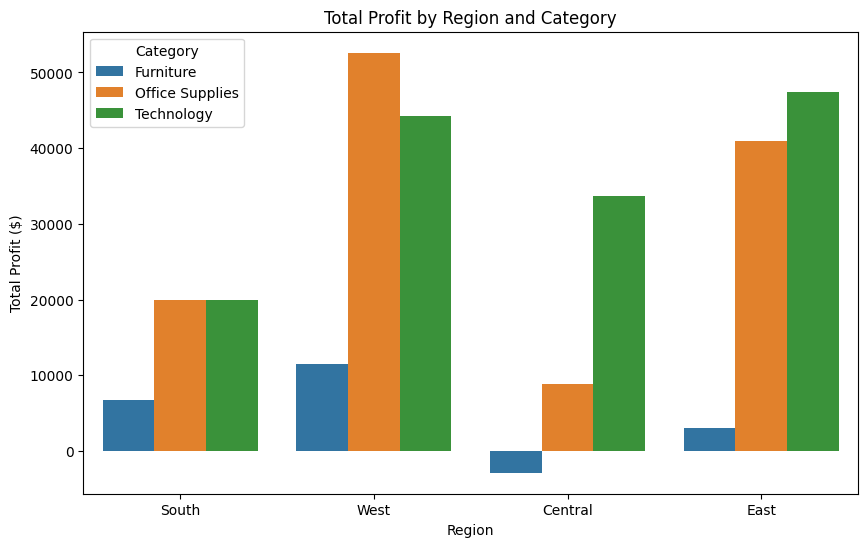

In [14]:
region_category_profit = df.groupby(["region", "category"])["profit"].sum().sort_values(ascending=False)
print(region_category_profit)

plt.figure(figsize=(10,6))
sns.barplot(data=df, x="region", y="profit", hue="category", estimator=sum, errorbar=None)
plt.title("Total Profit by Region and Category")
plt.ylabel("Total Profit ($)")
plt.xlabel("Region")
plt.legend(title="Category")
plt.show()

Q2: Which products lose money?

product_name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: profit, dtype: float64


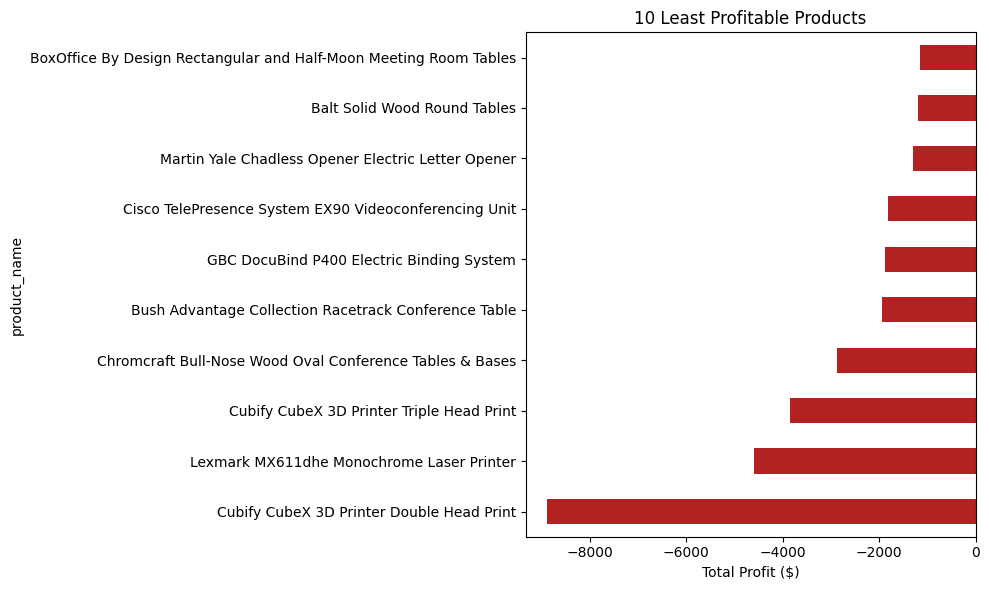

In [15]:
product_profit = df.groupby("product_name")["profit"].sum().sort_values()
worst_products = product_profit.head(10)
print(worst_products)

plt.figure(figsize=(10,6))
worst_products.plot(kind="barh", color="firebrick")
plt.title("10 Least Profitable Products")
plt.xlabel("Total Profit ($)")
plt.tight_layout()
plt.show()

Q3: How do sales trend by month?

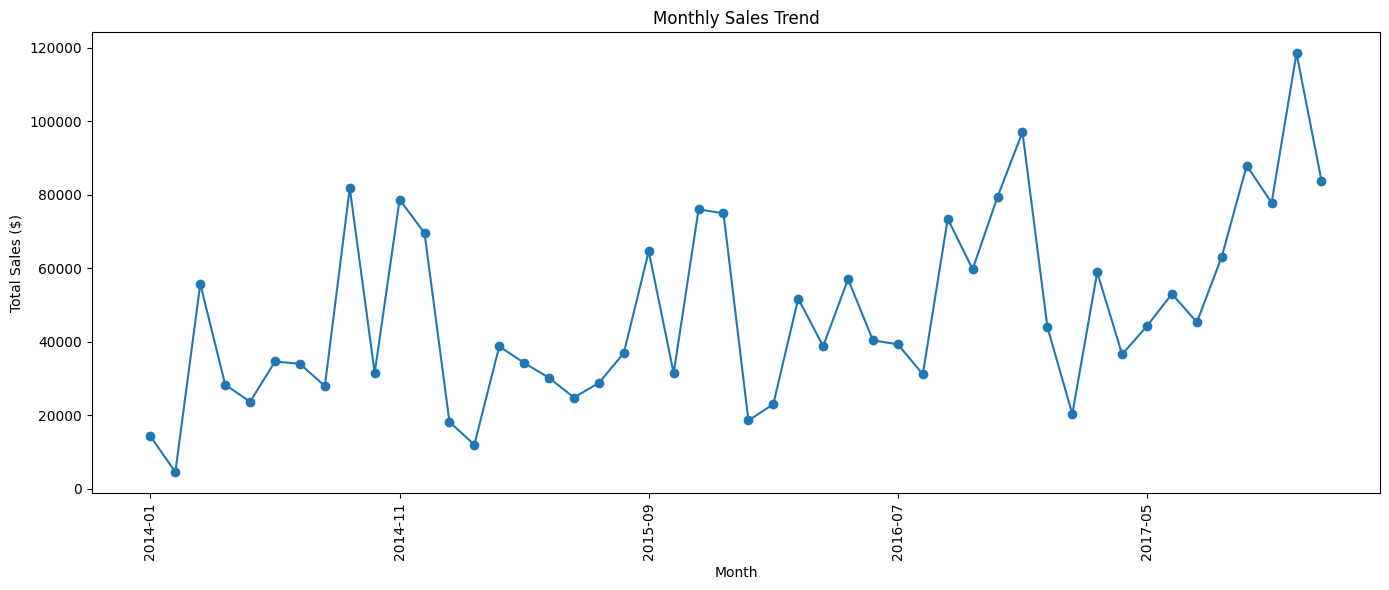

In [16]:
monthly_sales = df.groupby("month")["sales"].sum()

plt.figure(figsize=(14,6))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Total Sales ($)")
plt.xlabel("Month")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Q4: Does discount level affect profit?

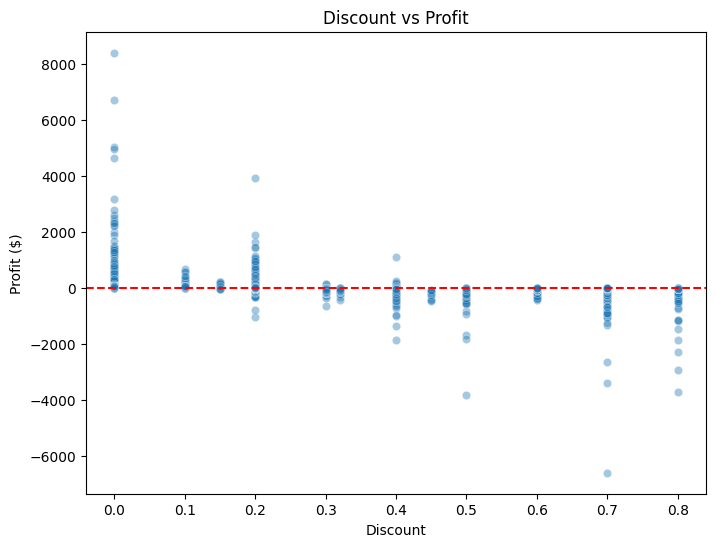

discount
0.00     66.900292
0.10     96.055074
0.15     27.288298
0.20     24.702572
0.30    -45.679636
0.32    -88.560656
0.40   -111.927429
0.45   -226.646464
0.50   -310.703456
0.60    -43.077212
0.70    -95.874060
0.80   -101.796797
Name: profit, dtype: float64


In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="discount", y="profit", alpha=0.4)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit ($)")
plt.axhline(0, color="red", linestyle="--")
plt.show()

# Average profit at each discount level
discount_profit = df.groupby("discount")["profit"].mean().sort_index()
print(discount_profit)

Q5: Who are the top 10 customers?

customer_name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: sales, dtype: float64


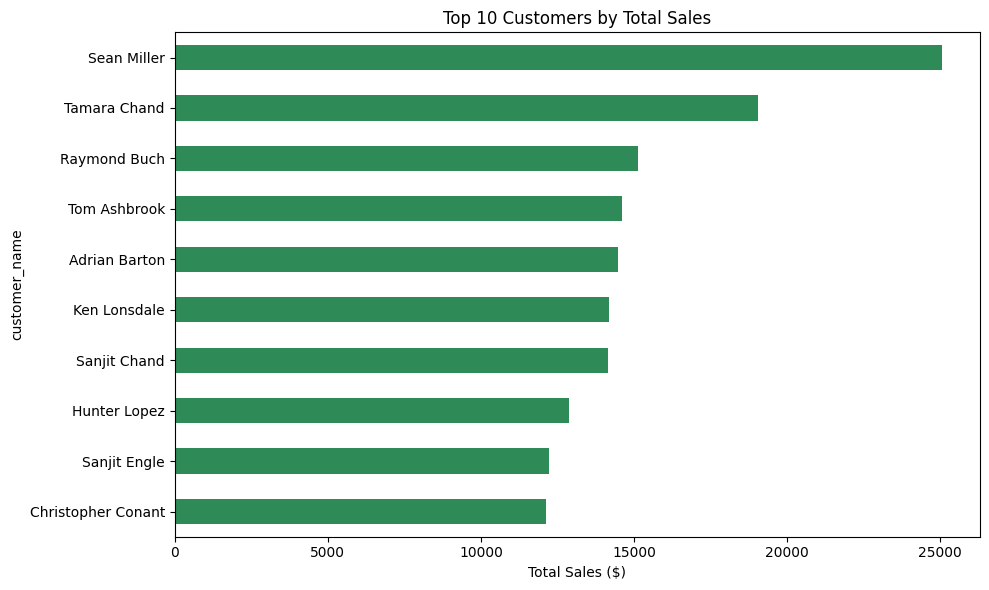

In [18]:
top_customers = df.groupby("customer_name")["sales"].sum().sort_values(ascending=False).head(10)
print(top_customers)

plt.figure(figsize=(10,6))
top_customers.plot(kind="barh", color="seagreen")
plt.title("Top 10 Customers by Total Sales")
plt.xlabel("Total Sales ($)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Key Insights and Recommendations

- **Sales show a clear year-over-year growth trend combined with a strong seasonal pattern:** revenue peaks every September–November and drops sharply every January, with the highest month on record (~$119,000) occurring in November 2017. The business should plan inventory and staffing ahead of the Q4 peak each year, and consider targeted promotions in January to smooth out the seasonal dip.

- **Discounts of 30% or more consistently produce a loss, while discounts up to 20% remain profitable** (average profit peaks around $96 per order at 10% discount, but falls to roughly -$311 at 50%). The business should cap standard discounts at 20% and treat anything above 30% as a deliberate clearance decision, not a default sales tactic.

- **Furniture consistently underperforms Technology and Office Supplies in every region, and Central Furniture is the only category-region combination operating at a loss (-$2,871)**, while West Office Supplies ($52,610) and East Technology ($47,462) are the strongest performers. Furniture pricing and shipping costs in the Central region should be reviewed before further investment there.

- **The Cubify CubeX 3D Printer (Double Head) is the single largest loss-making product at -$8,880**, more than double the next worst item, with several other large equipment items (printers, conference tables, a videoconferencing unit) also showing heavy losses — suggesting big-ticket items are being over-discounted. This product line's pricing should be reassessed or the line discontinued.

- **A small group of 10 customers each generated over $12,000 in sales, led by Sean Miller at roughly $25,000.** A loyalty program or dedicated account management for this group could help protect a disproportionately valuable slice of revenue.